In [6]:
#imports and setup
import os
import cv2
import torch
import torch.nn as nn
import numpy as np
from glob import glob
from tqdm import tqdm
import matplotlib.pyplot as plt

import albumentations as A
from albumentations.pytorch import ToTensorV2

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE =", DEVICE)

DATA_ROOT = "/workspace/ML Main Large/Processed data"
IMG_SIZE = 256
BATCH_SIZE = 4
EPOCHS = 20

DEVICE = cuda


In [7]:
#dataset loader
class RoadDataset(torch.utils.data.Dataset):
    def __init__(self, root, split, transform=None):
        img_dir = os.path.join(root, split, "images")
        mask_dir = os.path.join(root, split, "masks")

        self.img_paths = sorted(glob(os.path.join(img_dir, "*")))
        self.mask_paths = sorted(glob(os.path.join(mask_dir, "*"))) if os.path.isdir(mask_dir) else []
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.img_paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if len(self.mask_paths) > 0:
            mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)
            mask = (mask > 127).astype("float32")
        else:
            mask = np.zeros((img.shape[0], img.shape[1]), dtype="float32")

        if self.transform:
            aug = self.transform(image=img, mask=mask)
            img = aug["image"]
            mask = aug["mask"].unsqueeze(0)

        return img, mask

In [8]:
#Transforms
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.Normalize(),
    ToTensorV2()
])

valid_transform = A.Compose([
    A.Normalize(),
    ToTensorV2()
])

In [9]:
#HRNet-Small Model
class BasicBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class HRNetSmall(nn.Module):
    def __init__(self):
        super().__init__()

        self.stage1 = BasicBlock(3, 32)
        self.stage2 = BasicBlock(32, 64)
        self.stage3 = BasicBlock(64, 128)
        self.stage4 = BasicBlock(128, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)

        self.final = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        x1 = self.stage1(x)                         # 32 channels
        x2 = self.stage2(nn.MaxPool2d(2)(x1))       # 64 channels
        x3 = self.stage3(nn.MaxPool2d(2)(x2))       # 128
        x4 = self.stage4(nn.MaxPool2d(2)(x3))       # 256

        x = self.up3(x4)
        x = self.up2(x)
        x = self.up1(x)

        return self.final(x)

In [10]:
#Loss, IoU, Loaders
bce = nn.BCEWithLogitsLoss()

def dice_loss(pred, target):
    pred = torch.sigmoid(pred)
    smooth = 1e-6
    inter = (pred * target).sum()
    union = pred.sum() + target.sum()
    return 1 - (2*inter+smooth)/(union+smooth)

def total_loss(pred, target):
    return 0.5 * bce(pred, target) + 0.5 * dice_loss(pred, target)

def iou(pred, mask):
    pred = (torch.sigmoid(pred) > 0.5).float()
    inter = (pred * mask).sum()
    union = pred.sum() + mask.sum() - inter
    return (inter + 1e-6) / (union + 1e-6)

In [11]:
from torch.utils.data import DataLoader

train_ds = RoadDataset(DATA_ROOT, "train", train_transform)
valid_ds = RoadDataset(DATA_ROOT, "valid", valid_transform)  # empty masks = fine

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False)

In [12]:
#training loop
def train_hrnet():
    model = HRNetSmall().to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=1e-4)
    scaler = torch.cuda.amp.GradScaler()

    best_loss = float("inf")

    for epoch in range(1, EPOCHS+1):
        model.train()
        t_loss = t_iou = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}")
        for img, mask in pbar:
            img, mask = img.to(DEVICE), mask.to(DEVICE)

            opt.zero_grad()

            with torch.cuda.amp.autocast():
                pred = model(img)
                loss = total_loss(pred, mask)

            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()

            t_loss += loss.item()
            t_iou += iou(pred, mask).item()

            pbar.set_postfix(loss=t_loss/len(train_loader), iou=t_iou/len(train_loader))

        print(f"Train Loss: {t_loss/len(train_loader):.4f} | Train IoU: {t_iou/len(train_loader):.4f}")

        if t_loss < best_loss:
            best_loss = t_loss
            torch.save(model.state_dict(), "hrnet_small_best.pth")
            print("Saved BEST model!\n")

    print("Training complete.")
    return model

model = train_hrnet()


poch 1/20: 100%|██████████| 3672/3672 [03:34<00:00, 17.16it/s, iou=0.304, loss=0.334]   

Train Loss: 0.3338 | Train IoU: 0.3039
Saved BEST model!




poch 2/20: 100%|██████████| 3672/3672 [03:27<00:00, 17.72it/s, iou=0.382, loss=0.283]   

Train Loss: 0.2826 | Train IoU: 0.3822
Saved BEST model!




poch 3/20: 100%|██████████| 3672/3672 [03:36<00:00, 16.98it/s, iou=0.403, loss=0.27]    

...

Train Loss: 0.2370 | Train IoU: 0.4546
Saved BEST model!




poch 19/20: 100%|██████████| 3672/3672 [03:57<00:00, 15.48it/s, iou=0.455, loss=0.236]   

Train Loss: 0.2363 | Train IoU: 0.4555
Saved BEST model!



Epoch 20/20: 100%|██████████| 3672/3672 [03:50<00:00, 15.92it/s, iou=0.457, loss=0.235]   

Train Loss: 0.2354 | Train IoU: 0.4574
Saved BEST model!

Training complete.


In [14]:
#Prediction Function (valid/test)
def predict_mask(model, img_path):
    img = cv2.imread(img_path)
    if img is None:
        print("Cannot read", img_path)
        return None, None

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    aug = valid_transform(image=img)
    x = aug["image"].unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pred = torch.sigmoid(model(x))[0,0].cpu().numpy()

    pred = (pred * 255).astype("uint8")
    pred = cv2.resize(pred, (w, h))

    return img, pred

Showing: 15607_sat.jpg


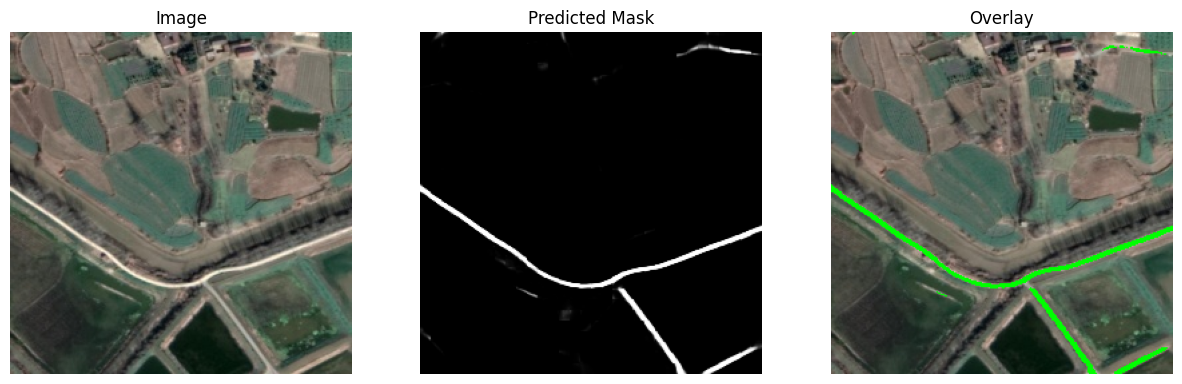

Showing: 15608_sat.jpg


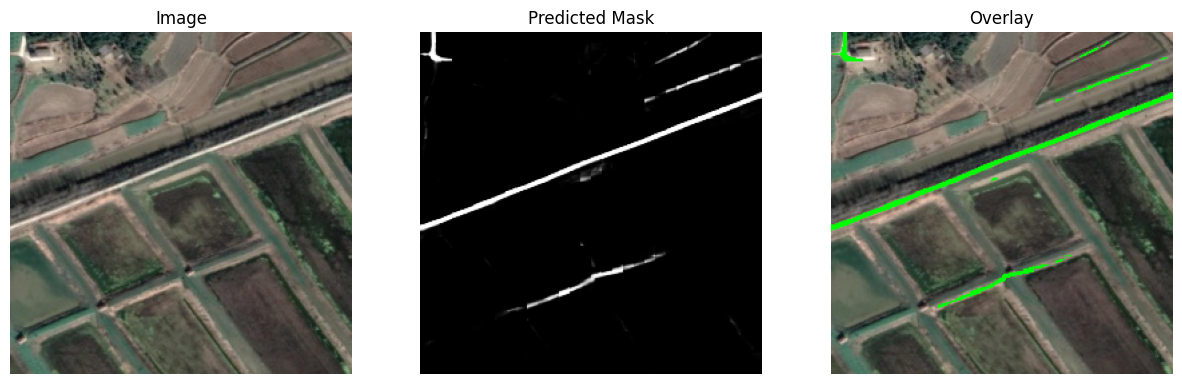

Showing: 15609_sat.jpg


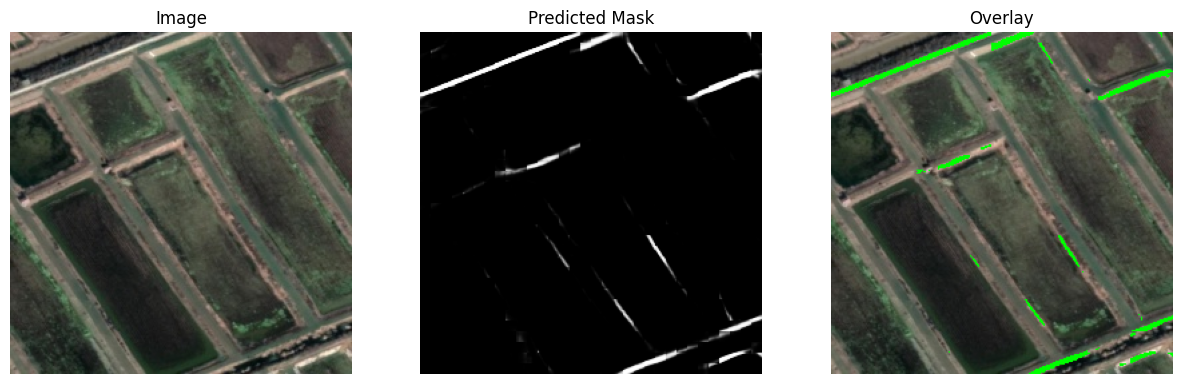

Showing: 15612_sat.jpg


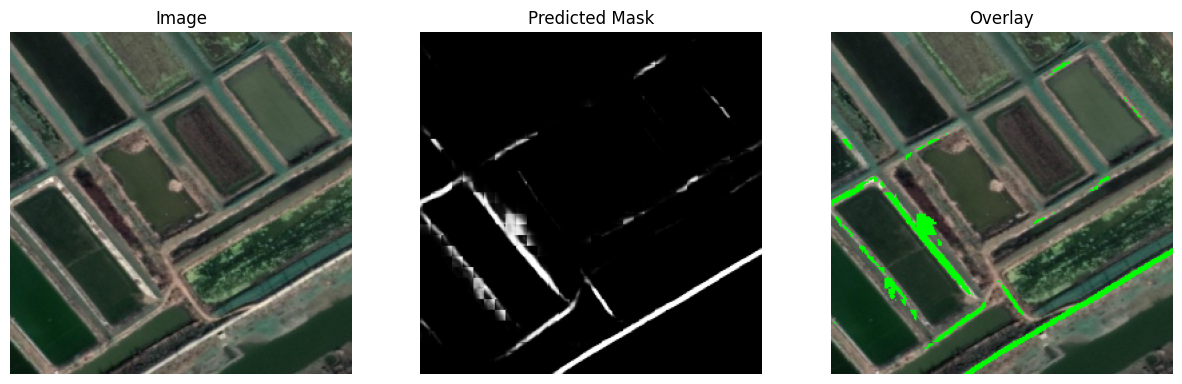

Showing: 15613_sat.jpg


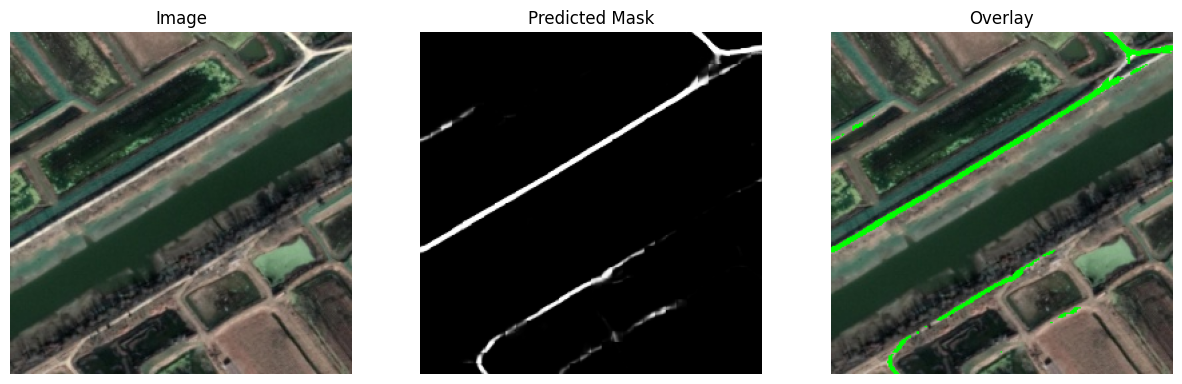

In [16]:
#Visualize Predictions
def show_prediction(img_path):
    img, mask = predict_mask(model, img_path)
    if img is None:
        return

    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.title("Image")
    plt.imshow(img)
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("Predicted Mask")
    plt.imshow(mask, cmap="gray")
    plt.axis("off")

    overlay = img.copy()
    overlay[mask > 127] = [0,255,0]

    plt.subplot(1,3,3)
    plt.title("Overlay")
    plt.imshow(overlay)
    plt.axis("off")
    plt.show()

# Show sample
TEST_DIR = "/workspace/ML Main Large/Processed data/test/images"
files = sorted(os.listdir(TEST_DIR))
for f in files[:5]:
    print("Showing:", f)
    show_prediction(os.path.join(TEST_DIR, f))

In [17]:
#  EVALUATION FUNCTION FOR HRNet-Small (already trained)

def evaluate_saved_model(model_path, dataset, batch_size=4, num_samples_to_show=3):
    """
    Loads a saved HRNetSmall model and evaluates it on a dataset.
    
    - Computes mean loss + IoU (only if masks exist)
    - Shows predictions on a few samples
    """

    print("\nLoading saved model from:", model_path)

    # 1. Load model
    model = HRNetSmall().to(DEVICE)
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.eval()

    # 2. DataLoader
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    total_loss_value = 0.0
    total_iou_value = 0.0
    count_batches = 0
    has_masks = False

    print("\nEvaluating...")
    pbar = tqdm(loader)

    with torch.no_grad():
        for imgs, masks in pbar:
            imgs = imgs.to(DEVICE)
            masks = masks.to(DEVICE)

            preds = model(imgs)

            # check if masks actually contain data
            if masks.sum() > 0:
                has_masks = True
                loss = total_loss(preds, masks)
                total_loss_value += loss.item()
                total_iou_value += iou(preds, masks).item()

            count_batches += 1

    if has_masks:
        avg_loss = total_loss_value / count_batches
        avg_iou = total_iou_value / count_batches
        print(f"\n✅ Evaluation complete:")
        print(f"   → Mean Loss: {avg_loss:.4f}")
        print(f"   → Mean IoU : {avg_iou:.4f}")
    else:
        print("\nNo masks found in dataset — skipping IoU/Loss computation.")

    # SHOW SAMPLE PREDICTIONS
    print(f"\nShowing {num_samples_to_show} sample predictions...")

    for i in range(num_samples_to_show):
        img, true_mask = dataset[i]
        orig_img = img.permute(1,2,0).cpu().numpy()
        orig_img = (orig_img * 255).astype("uint8")

        inp = img.unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            pred = torch.sigmoid(model(inp))[0, 0].cpu().numpy()

        pred_mask = (pred > 0.5).astype("uint8") * 255

        # Create overlay
        overlay = orig_img.copy()
        overlay[pred_mask > 127] = [0, 255, 0]

        # Plot
        plt.figure(figsize=(12,4))
        plt.subplot(1,3,1)
        plt.imshow(orig_img)
        plt.title("Image")
        plt.axis("off")

        plt.subplot(1,3,2)
        plt.imshow(pred_mask, cmap="gray")
        plt.title("Predicted Mask")
        plt.axis("off")

        plt.subplot(1,3,3)
        plt.imshow(overlay)
        plt.title("Overlay")
        plt.axis("off")

        plt.show()

    print("\nEvaluation + visualization done!")


Loading saved model from: hrnet_small_best.pth

Evaluating...


100%|██████████| 3672/3672 [04:30<00:00, 13.56it/s]


✅ Evaluation complete:
   → Mean Loss: 0.2293
   → Mean IoU : 0.4591

Showing 3 sample predictions...


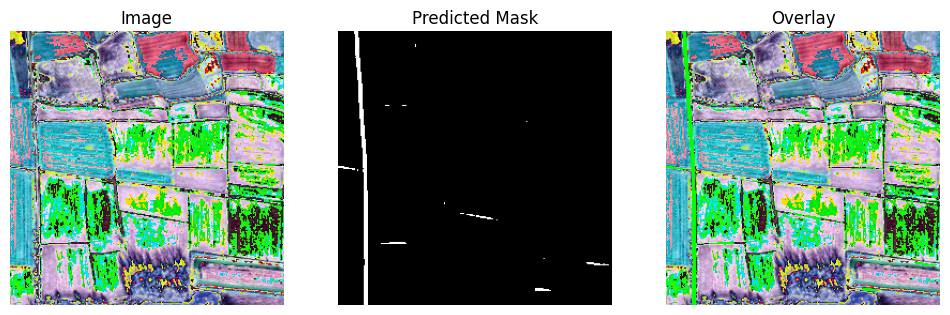

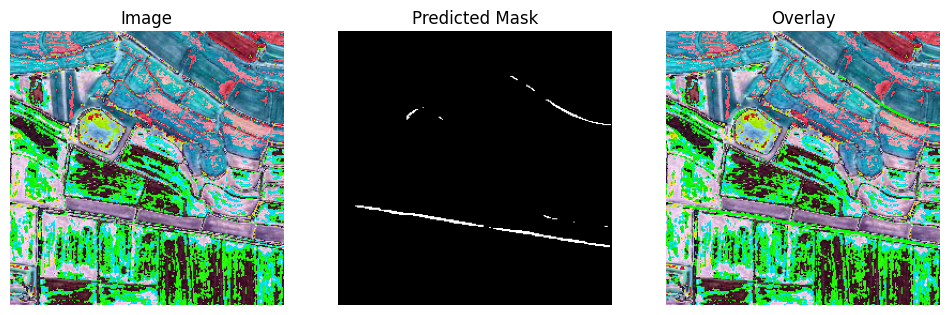

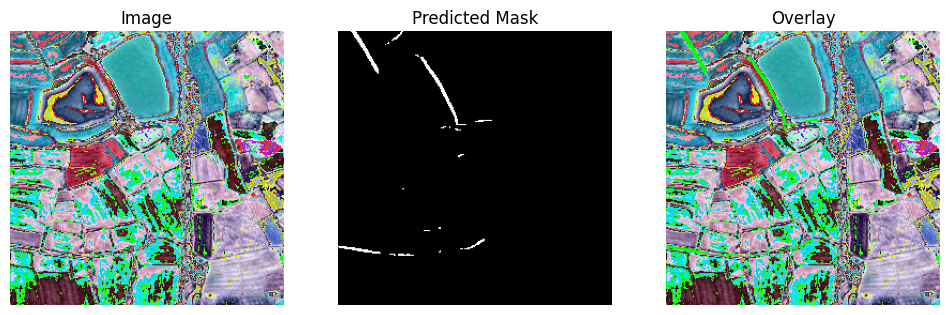


Evaluation + visualization done!


In [18]:
train_ds = RoadDataset(DATA_ROOT, "train", valid_transform)  
evaluate_saved_model("hrnet_small_best.pth", train_ds)